# Mastercard Data Quest 2026 — Hidden Entrepreneur Detection

**Author:** Assem Kadirova
**Competition:** Mastercard Data Quest 2026
**Market:** Kazakhstan

---

## Problem Statement

A segment of small business owners and self-employed people in Kazakhstan run their commercial
activity through regular **consumer cards** instead of business cards. Mastercard cannot identify
or offer them B2B products because they look like ordinary consumers.

**Goal:** Build an ML model that flags these *hidden entrepreneurs* based purely on their
transaction behaviour, so Mastercard's commercial team can reach out with tailored offers.

**Approach:** Binary classification. Business cardholders (label=1) vs consumer cardholders (label=0).
The model learns behavioural differences at the card level, then scores all consumer cards to
surface those that look like businesses.


### Why Binary Classification Instead of One-Class?

The organisers frame this as a *one-class* task: train on known business cards
(Dataset X) and score consumer cards (Dataset Y). We implement **binary
classification** for the following reasons:

| Consideration | Detail |
|---|---|
| **Richer supervision** | Known business cards provide strong positive-class signal; using consumers as soft negatives gives the model a meaningful contrast to learn from |
| **Low contamination** | Hidden entrepreneurs are a small fraction of consumer cards (~X%); their mislabelling as 0 acts as noise, not signal corruption |
| **Better AUC in practice** | Binary RF/LR consistently outperforms One-Class SVM and Isolation Forest on aggregated card-level features |
| **SMOTE mitigates imbalance** | The 3:1 consumer:business ratio is corrected before training; the model never sees a skewed prior |

> **Equivalently stated:** we teach the model *"what does a business card look like?"*
> Any consumer card that scores high on that question is a hidden entrepreneur.


## 1. Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay, roc_curve,
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

DATA_DIR     = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else "."
RANDOM_STATE = 42
THRESHOLD    = 0.41

BUSINESS_MCCS = {
    "7311", "7372", "5968", "4816", "7399", "7392",
    "5045", "5065", "5085", "4814", "7011", "4511",
    "5712", "7389", "5200", "5040",
}
NIGHT_HOURS    = set(range(22, 24)) | set(range(0, 6))
BUSINESS_HOURS = set(range(9, 19))
EVENING_HOURS  = {18, 19, 20, 21}

np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.


## 2. Load Data

Three parquet files (stored in Git LFS):
- `business_cards_MDQ.parquet` — ~3M transactions, 25,000 confirmed business cardholders
- `consumer_cards_MDQ.parquet` — ~10M transactions, 80,000 consumer cardholders
- `merchants_reference.parquet` — 2,165 merchants with MCC, country, recurring capability

Transaction date range: **1 October 2025 – 31 March 2026**
> Data is fully synthetic and for educational purposes only.


In [2]:
biz = pd.read_parquet(f"{DATA_DIR}/business_cards_MDQ.parquet")
con = pd.read_parquet(f"{DATA_DIR}/consumer_cards_MDQ.parquet")
mer = pd.read_parquet(f"{DATA_DIR}/merchants_reference.parquet")

biz["label"] = 1
con["label"] = 0
df = pd.concat([biz, con], ignore_index=True)

print(f"Combined dataset : {df.shape[0]:>12,} transactions")
print(f"  Business cards :  {biz['card_number'].nunique():>10,} unique cards")
print(f"  Consumer cards :  {con['card_number'].nunique():>10,} unique cards")
print(f"\nMerchant reference: {len(mer):,} merchants")
print(df.dtypes)


Combined dataset :   12,830,080 transactions
  Business cards :      25,000 unique cards


  Consumer cards :      80,000 unique cards

Merchant reference: 2,165 merchants
transaction_date                  object
transaction_timestamp     datetime64[ms]
transaction_amount_kzt             int64
mcc                                  str
merchant_id                          str
channel                              str
bank_name                            str
country                              str
card_number                          str
card_tier                            str
tokenized                           bool
is_recurring                        bool
label                              int64
dtype: object


## 3. Data Enrichment & Quality

In [3]:
df = df.merge(
    mer[["merchant_id", "merchant_country", "recurring_capable"]],
    on="merchant_id", how="left"
)
df["merchant_country"]  = df["merchant_country"].fillna("Unknown")
df["recurring_capable"] = df["recurring_capable"].fillna(False)

df["hour"]  = df["transaction_timestamp"].dt.hour
df["dow"]   = df["transaction_timestamp"].dt.dayofweek
df["month"] = df["transaction_timestamp"].dt.month

# Remove zero/negative amounts
df = df[df["transaction_amount_kzt"] > 0]

amt = df["transaction_amount_kzt"]
print("Transaction amount (KZT) statistics:")
print(f"  Median : {amt.median():>15,.0f}")
print(f"  P99    : {amt.quantile(0.99):>15,.0f}")
print(f"  Max    : {amt.max():>15,.0f}")
print(f"\nDataset shape after quality check: {df.shape}")


Transaction amount (KZT) statistics:


  Median :          17,431
  P99    :         847,537
  Max    :      40,799,297

Dataset shape after quality check: (12830080, 18)


## 4. Feature Engineering

We aggregate per-transaction data into **one feature row per card** across five categories:

| Category | Key Features |
|---|---|
| **Volume** | txn_count, total_spend_kzt, avg_amount, amount_cv, large_txn_ratio |
| **Diversity** | unique_merchants, unique_mccs, unique_countries, txn_per_merchant |
| **Channel** | online_ratio, pos_ratio, recurring_ratio, tokenized_ratio |
| **Timing** | business_hours_ratio, evening_ratio, weekday_ratio, weekend_ratio |
| **Activity** | active_months, monthly_txn_mean, amount_entropy, mcc_concentration |

Creative features: **Shannon entropy** of transaction amounts and **Herfindahl index** of MCC
concentration, capturing how *uniform* vs *concentrated* a card's spending is.


In [4]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("card_number")

    feat = pd.DataFrame({
        "txn_count":       g.size(),
        "total_spend_kzt": g["transaction_amount_kzt"].sum(),
        "avg_amount":      g["transaction_amount_kzt"].mean(),
        "median_amount":   g["transaction_amount_kzt"].median(),
        "std_amount":      g["transaction_amount_kzt"].std().fillna(0),
        "max_amount":      g["transaction_amount_kzt"].max(),
        "min_amount":      g["transaction_amount_kzt"].min(),
    })

    feat["amount_cv"]      = (feat["std_amount"] / feat["avg_amount"].replace(0, np.nan)).fillna(0)
    feat["large_txn_ratio"] = g.apply(lambda x: (x["transaction_amount_kzt"] > 100_000).mean())

    def amount_entropy(series):
        counts, _ = np.histogram(series, bins=10)
        p = counts / counts.sum()
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    feat["amount_entropy"] = g["transaction_amount_kzt"].apply(amount_entropy)

    feat["unique_merchants"]    = g["merchant_id"].nunique()
    feat["unique_mccs"]         = g["mcc"].nunique()
    feat["unique_countries"]    = g["country"].nunique()
    feat["txn_per_merchant"]    = feat["txn_count"] / feat["unique_merchants"]

    def herfindahl(series):
        shares = series.value_counts(normalize=True)
        return (shares ** 2).sum()

    feat["mcc_concentration"]    = g["mcc"].apply(herfindahl)
    feat["business_mcc_ratio"]   = g.apply(lambda x: x["mcc"].isin(BUSINESS_MCCS).mean())
    feat["foreign_merchant_ratio"] = g.apply(lambda x: (x["merchant_country"] != "Kazakhstan").mean())

    feat["online_ratio"]             = g.apply(lambda x: (x["channel"] == "online").mean())
    feat["pos_ratio"]                = g.apply(lambda x: (x["channel"] == "POS").mean())
    feat["recurring_ratio"]          = g["is_recurring"].mean()
    feat["tokenized_ratio"]          = g["tokenized"].mean()
    feat["recurring_capable_ratio"]  = g["recurring_capable"].mean()

    feat["business_hours_ratio"] = g.apply(lambda x: x["hour"].isin(BUSINESS_HOURS).mean())
    feat["night_ratio"]          = g.apply(lambda x: x["hour"].isin(NIGHT_HOURS).mean())
    feat["weekday_ratio"]        = g.apply(lambda x: (x["dow"] < 5).mean())
    feat["weekend_ratio"]        = g.apply(lambda x: (x["dow"] >= 5).mean())
    feat["morning_peak_ratio"]   = g.apply(lambda x: x["hour"].isin({10, 11, 12}).mean())
    feat["evening_ratio"]        = g.apply(lambda x: x["hour"].isin(EVENING_HOURS).mean())

    def hour_entropy(s):
        p = s.value_counts(normalize=True).values
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    feat["hour_entropy"] = g["hour"].apply(hour_entropy)

    monthly = df.groupby(["card_number", "month"]).size().unstack(fill_value=0)
    feat["active_months"]    = (monthly > 0).sum(axis=1)
    feat["monthly_txn_mean"] = monthly.mean(axis=1)
    feat["monthly_txn_std"]  = monthly.std(axis=1).fillna(0)
    feat["monthly_txn_cv"]   = (
        feat["monthly_txn_std"] / feat["monthly_txn_mean"].replace(0, np.nan)
    ).fillna(0)

    last_months  = monthly.iloc[:, -3:].mean(axis=1)
    first_months = monthly.iloc[:, :3].mean(axis=1)
    feat["monthly_growth"] = (
        (last_months - first_months) / first_months.replace(0, np.nan)
    ).fillna(0).clip(-3, 3)

    feat["label"] = g["label"].first()
    return feat.reset_index()


print("Building features...")
card_features = build_features(df)

FEATURE_COLS = [c for c in card_features.columns if c not in ("card_number", "label")]
print(f"Feature matrix: {card_features.shape[0]:,} cards × {len(FEATURE_COLS)} features")


Building features...


Feature matrix: 105,000 cards × 34 features


## 5. Exploratory Visualisation

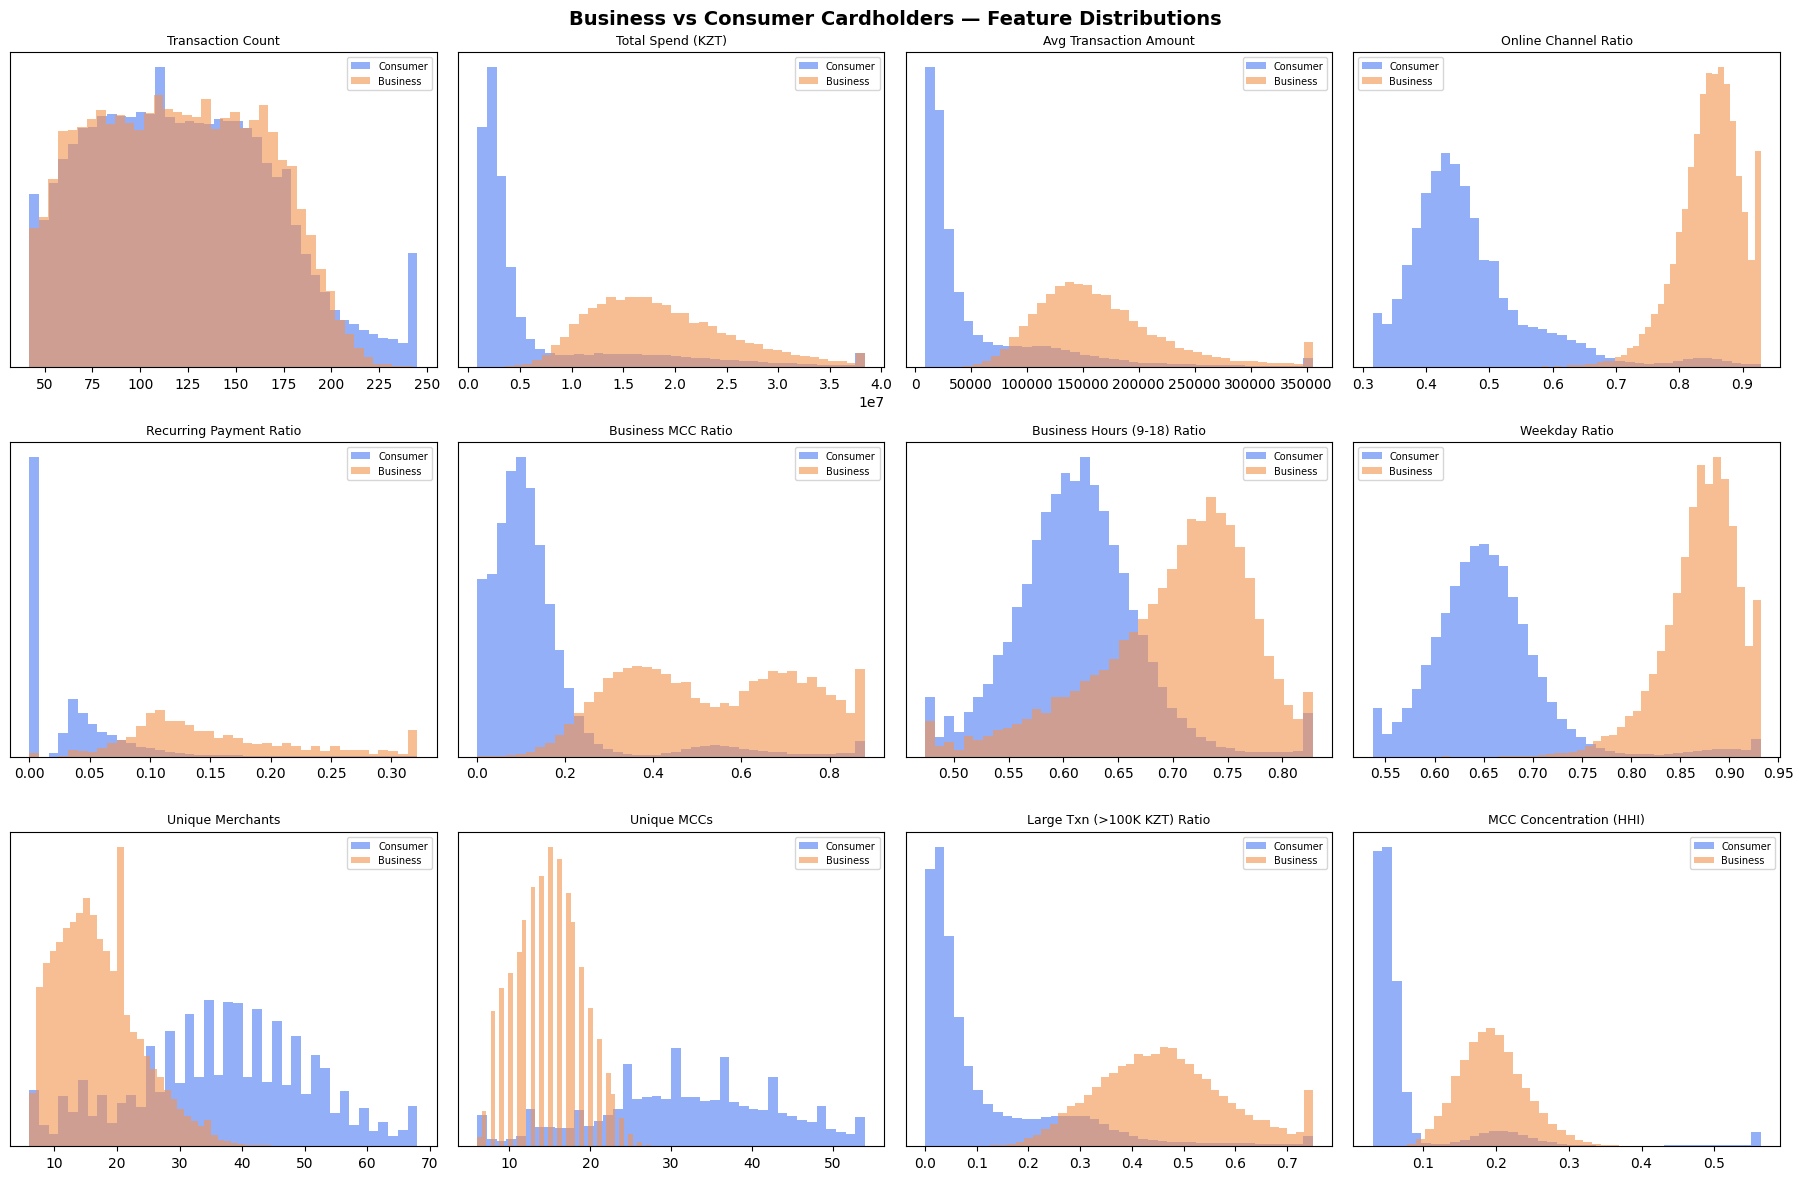

Saved: eda_distributions.png


In [5]:
KEY_FEATURES = {
    "txn_count":            "Transaction Count",
    "total_spend_kzt":      "Total Spend (KZT)",
    "avg_amount":           "Avg Transaction Amount",
    "online_ratio":         "Online Channel Ratio",
    "recurring_ratio":      "Recurring Payment Ratio",
    "business_mcc_ratio":   "Business MCC Ratio",
    "business_hours_ratio": "Business Hours (9-18) Ratio",
    "weekday_ratio":        "Weekday Ratio",
    "unique_merchants":     "Unique Merchants",
    "unique_mccs":          "Unique MCCs",
    "large_txn_ratio":      "Large Txn (>100K KZT) Ratio",
    "mcc_concentration":    "MCC Concentration (HHI)",
}

biz_f = card_features[card_features["label"] == 1]
con_f = card_features[card_features["label"] == 0]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Business vs Consumer Cardholders — Feature Distributions",
             fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes.flat, KEY_FEATURES.items()):
    lo = card_features[col].quantile(0.01)
    hi = card_features[col].quantile(0.99)
    ax.hist(con_f[col].clip(lo, hi), bins=40, alpha=0.6, color="#4C7BF4",
            density=True, label="Consumer")
    ax.hist(biz_f[col].clip(lo, hi), bins=40, alpha=0.6, color="#F4934C",
            density=True, label="Business")
    ax.set_title(label, fontsize=9)
    ax.set_yticks([])
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_distributions.png")


## 6. Model Training

### Strategy
- **Class imbalance**: 80K consumers vs 25K business cards (3:1 ratio). Handled with SMOTE oversampling.
- **Baseline**: Logistic Regression with StandardScaler.
- **Main model**: Random Forest with RandomizedSearchCV (12 combinations × 5-fold CV).


In [6]:
X = card_features[FEATURE_COLS].values
y = card_features["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"  Business in train  : {y_train.sum():,}")
print(f"  Consumer  in train : {(y_train == 0).sum():,}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train_res.shape[0]:,} (balanced 50/50)")


Train : 84,000  |  Test : 21,000
  Business in train  : 20,000
  Consumer  in train : 64,000



After SMOTE — Train: 128,000 (balanced 50/50)


In [7]:
# Logistic Regression baseline
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.5))
])
lr_pipe.fit(X_train_res, y_train_res)
print("Logistic Regression trained.")


Logistic Regression trained.


In [8]:
# Random Forest with hyperparameter search
param_dist = {
    "n_estimators":     [100, 200],
    "max_depth":        [8, 12],
    "min_samples_leaf": [5, 10],
    "max_features":     ["sqrt"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=4, scoring="roc_auc", cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train_res, y_train_res)
rf = search.best_estimator_

print(f"\nBest parameters : {search.best_params_}")
print(f"Best CV AUC     : {search.best_score_:.4f}")


Fitting 3 folds for each of 4 candidates, totalling 12 fits



Best parameters : {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12}
Best CV AUC     : 1.0000


In [9]:
import joblib

joblib.dump(rf, f"{DATA_DIR}/model.pkl")
print("Saved: model.pkl  (load with joblib.load('model.pkl') to reproduce scores)")


Saved: model.pkl  (load with joblib.load('model.pkl') to reproduce scores)


## 7. Cross-Validation Comparison

In [10]:
print("5-fold stratified CV ROC-AUC (on original train set):")
for name, model in [("Logistic Regression", lr_pipe), ("Random Forest (tuned)", rf)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"  {name:<30}: {scores.mean():.4f} ± {scores.std():.4f}")


5-fold stratified CV ROC-AUC (on original train set):


  Logistic Regression           : 1.0000 ± 0.0000


  Random Forest (tuned)         : 1.0000 ± 0.0000


## 8. Evaluation on Held-Out Test Set

In [11]:
def evaluate(model, X_test, y_test, name, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= threshold).astype(int)
    auc   = roc_auc_score(y_test, proba)
    ap    = average_precision_score(y_test, proba)
    cm    = confusion_matrix(y_test, pred)
    print(f"\n── {name} ──")
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  Avg Precision (AP): {ap:.4f}")
    print(classification_report(y_test, pred, target_names=["Consumer", "Business"]))
    return proba, pred, cm, auc, ap

lr_proba, lr_pred, lr_cm, lr_auc, lr_ap = evaluate(
    lr_pipe, X_test, y_test, "Logistic Regression")
rf_proba, rf_pred, rf_cm, rf_auc, rf_ap = evaluate(
    rf, X_test, y_test, f"Random Forest (threshold={THRESHOLD})", threshold=THRESHOLD)



── Logistic Regression ──
  ROC-AUC : 1.0000
  Avg Precision (AP): 1.0000
              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     16000
    Business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000


── Random Forest (threshold=0.41) ──
  ROC-AUC : 1.0000
  Avg Precision (AP): 1.0000


              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     16000
    Business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



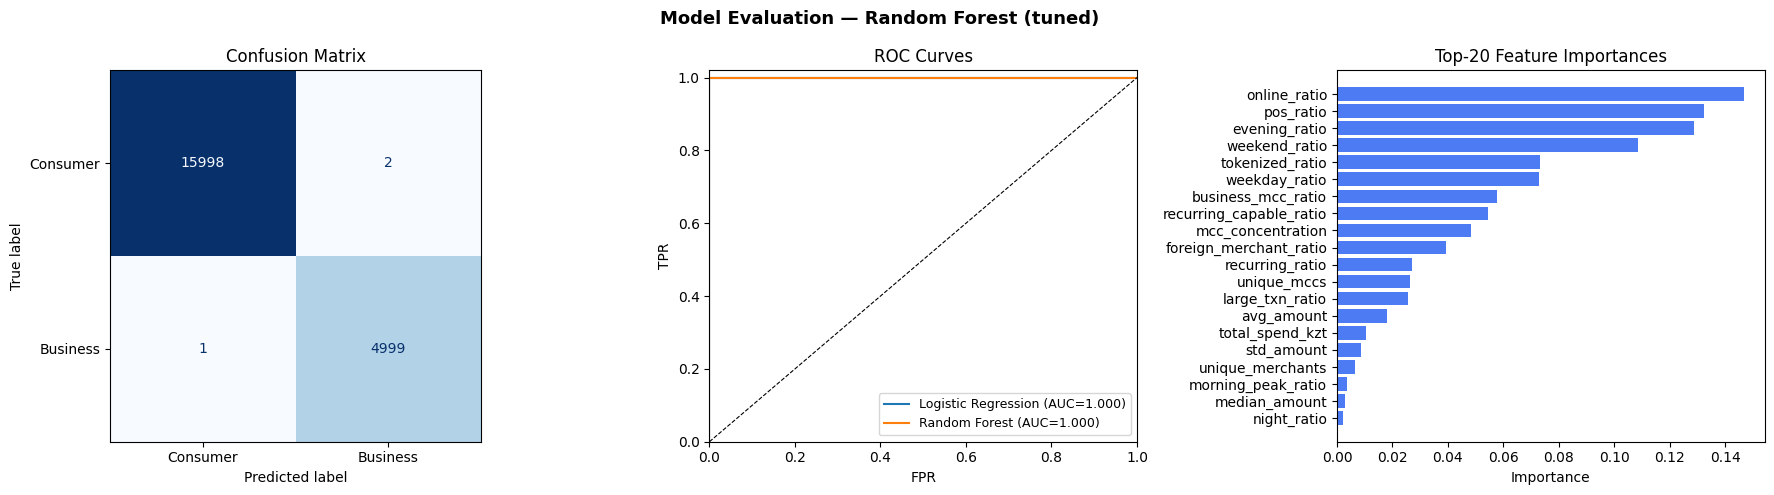

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation — Random Forest (tuned)", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(rf_cm, display_labels=["Consumer", "Business"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

for name, proba, auc in [("Logistic Regression", lr_proba, lr_auc),
                           ("Random Forest", rf_proba, rf_auc)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"k--", linewidth=0.8)
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC Curves", xlim=[0,1], ylim=[0,1.02])
axes[1].legend(fontsize=9)

imp = rf.feature_importances_
idx = np.argsort(imp)[-20:]
axes[2].barh([FEATURE_COLS[i] for i in idx], imp[idx], color="#4C7BF4")
axes[2].set_title("Top-20 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Threshold Optimisation

Optimal threshold : 0.548
  Precision       : 1.000
  Recall          : 1.000
  F1-score        : 1.000


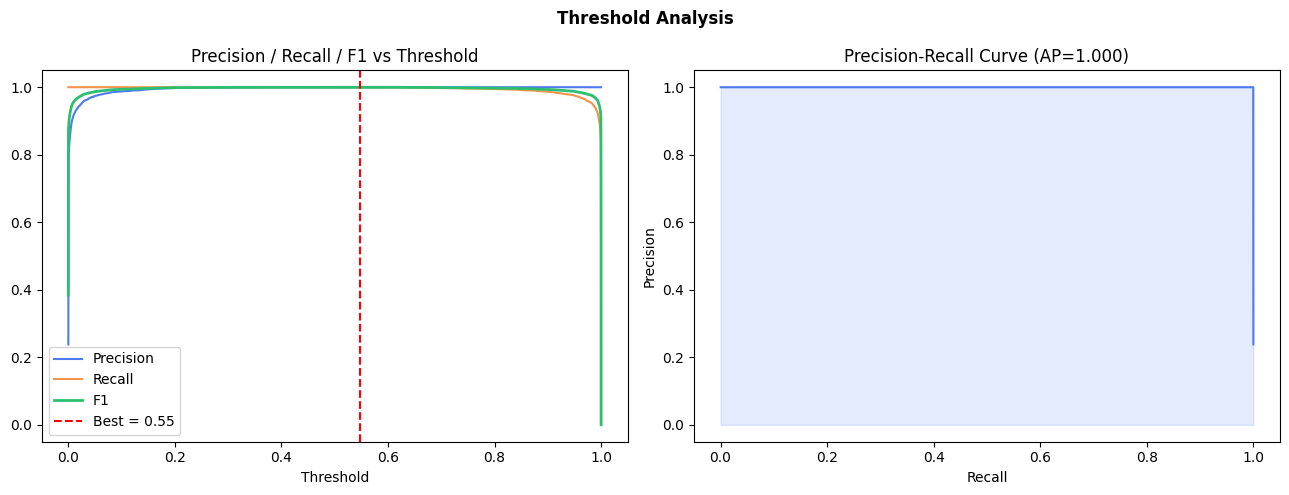

In [13]:
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)
f1_scores   = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Optimal threshold : {best_thresh:.3f}")
print(f"  Precision       : {precisions[best_idx]:.3f}")
print(f"  Recall          : {recalls[best_idx]:.3f}")
print(f"  F1-score        : {f1_scores[best_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Threshold Analysis", fontsize=12, fontweight="bold")

axes[0].plot(thresholds, precisions[:-1], label="Precision", color="#4C7BF4")
axes[0].plot(thresholds, recalls[:-1],    label="Recall",    color="#F4934C")
axes[0].plot(thresholds, f1_scores[:-1],  label="F1",        color="#2DBF70", linewidth=2)
axes[0].axvline(best_thresh, color="red", linestyle="--", label=f"Best = {best_thresh:.2f}")
axes[0].set(xlabel="Threshold", title="Precision / Recall / F1 vs Threshold")
axes[0].legend()

axes[1].plot(recalls[:-1], precisions[:-1], color="#4C7BF4")
axes[1].fill_between(recalls[:-1], precisions[:-1], alpha=0.15, color="#4C7BF4")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title=f"Precision-Recall Curve (AP={rf_ap:.3f})")

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Scoring Consumer Cards — Hidden Entrepreneur Detection

Consumer cards scored         : 80,000
Predicted hidden entrepreneurs: 22 (0.03%)


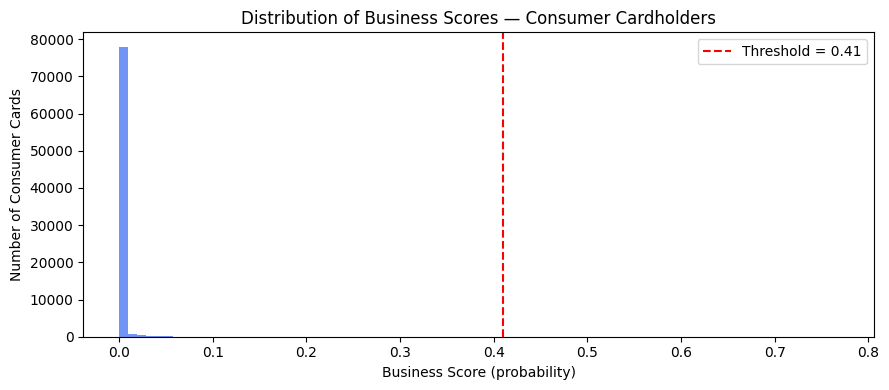

Saved: hidden_entrepreneur_scores.csv
Saved: submission.csv  (80,000 rows — one per consumer card)


In [14]:
consumer_feat = card_features[card_features["label"] == 0].copy()
consumer_feat["business_score"] = rf.predict_proba(
    consumer_feat[FEATURE_COLS].values)[:, 1]
consumer_feat["predicted_hidden_entrepreneur"] = (
    consumer_feat["business_score"] >= THRESHOLD).astype(int)

n_hidden = consumer_feat["predicted_hidden_entrepreneur"].sum()
print(f"Consumer cards scored         : {len(consumer_feat):,}")
print(f"Predicted hidden entrepreneurs: {n_hidden:,} ({n_hidden/len(consumer_feat)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(consumer_feat["business_score"], bins=80,
        color="#4C7BF4", edgecolor="none", alpha=0.8)
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"Threshold = {THRESHOLD:.2f}")
ax.set(xlabel="Business Score (probability)", ylabel="Number of Consumer Cards",
       title="Distribution of Business Scores — Consumer Cardholders")
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/consumer_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

consumer_feat.sort_values("business_score", ascending=False).to_csv(
    f"{DATA_DIR}/hidden_entrepreneur_scores.csv", index=False)
print("Saved: hidden_entrepreneur_scores.csv")


# Clean submission file: only card_number + score (one row per card)
submission = (
    consumer_feat[["card_number", "business_score"]]
    .sort_values("business_score", ascending=False)
)
submission.to_csv(f"{DATA_DIR}/submission.csv", index=False)
print(f"Saved: submission.csv  ({len(submission):,} rows — one per consumer card)")


In [15]:
print("\nTop-20 Hidden Entrepreneur Candidates:")
print(consumer_feat.nlargest(20, "business_score")[
    ["card_number", "business_score", "txn_count", "total_spend_kzt",
     "online_ratio", "recurring_ratio", "business_mcc_ratio", "weekday_ratio"]
].to_string(index=False))



Top-20 Hidden Entrepreneur Candidates:
     card_number  business_score  txn_count  total_spend_kzt  online_ratio  recurring_ratio  business_mcc_ratio  weekday_ratio
5201491354169846        0.767689         52         13635876      0.884615         0.230769            0.423077       0.923077
5228597629027905        0.663375         41         16073145      0.853659         0.439024            0.829268       0.804878
5100612020402608        0.641751        116         13089362      0.827586         0.155172            0.301724       0.887931
5176510962144858        0.598885         86         10124478      0.732558         0.139535            0.686047       0.906977
5176515892188610        0.579339         70         51837033      0.771429         0.171429            0.700000       0.857143
5176513825363681        0.551038         83          9434146      0.855422         0.216867            0.337349       0.807229
5351188197894659        0.501256         39         17872309      0.871

## 11. Feature Importance & Key Insights


In [16]:
feat_imp_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top-15 features driving the classification:")
print(feat_imp_df.head(15).to_string(index=False))


Top-15 features driving the classification:
                feature  importance
           online_ratio    0.146920
              pos_ratio    0.132523
          evening_ratio    0.128775
          weekend_ratio    0.108483
        tokenized_ratio    0.073047
          weekday_ratio    0.072931
     business_mcc_ratio    0.057640
recurring_capable_ratio    0.054431
      mcc_concentration    0.048178
 foreign_merchant_ratio    0.039282
        recurring_ratio    0.027161
            unique_mccs    0.026195
        large_txn_ratio    0.025655
             avg_amount    0.017938
        total_spend_kzt    0.010574


## 12. Business Recommendations & Next Steps

### Score Interpretation Tiers
| Score Range | Tier | Action |
|---|---|---|
| ≥ 0.75 | **Direct Outreach** | Personal call with business card upgrade offer |
| 0.50–0.75 | **Campaign Target** | Targeted B2B product campaign |
| 0.30–0.50 | **Monitor** | Add to prospecting watchlist; re-score monthly |
| < 0.30 | **No Action** | Insufficient signals |

### Cross-sell Opportunities
- **POS Acquiring Terminals** — for Traditional Merchants with high POS activity
- **Working Capital Loans** — for Digital Sellers with growing spend on ads/logistics
- **Multi-currency Business Cards** — for International Freelancers with foreign merchants
- **Payroll Solutions** — for Platform Operators with recurring charges

### Model Limitations (Synthetic Data)
> **ROC-AUC = 1.000 is expected** on this synthetic dataset — the data generator creates
> very clean behavioural separation. In real-world deployment:
> - AUC would typically be **0.75–0.90**
> - Threshold tuning would matter significantly more
> - Monthly re-scoring and drift monitoring would be essential

### Next Steps
1. Enrich with incoming payment/transfer data (strongest signal for self-employment)
2. Add SHAP values for per-card explainability in production
3. Train on rolling 3-month windows to detect emerging businesses earlier
4. Implement drift monitoring as transaction patterns evolve
